# Credit Card Default Prediction — Data Cleaning & Feature Engineering

Handle missing values, engineer features, encode categoricals, save cleaned dataset.

## 1. Imports & Load Raw Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')
from utils import load_data, preprocess_data, create_features

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
%matplotlib inline

In [2]:
df = load_data()
print('Raw shape:', df.shape)
df.head()

Raw shape: (30000, 24)


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,20000.0,2,2,1,24,2,2,-1,-1,-2,-2,3913.0,3102.0,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,120000.0,2,2,2,26,-1,2,0,0,0,2,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,90000.0,2,2,2,34,0,0,0,0,0,0,29239.0,14027.0,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,50000.0,2,2,1,37,0,0,0,0,0,0,46990.0,48233.0,49291.0,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,50000.0,1,2,1,57,-1,0,-1,0,0,0,8617.0,5670.0,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


## 2. Handle Missing / Invalid Values

In [3]:
# In this dataset there are no NaN values, but some categorical codes are invalid:
# EDUCATION ∈ {0,5,6} → fold into 'Other' (4); MARRIAGE 0 → 'Other' (3).
print('EDUCATION codes:', df['EDUCATION'].value_counts().to_dict())
print('MARRIAGE codes:', df['MARRIAGE'].value_counts().to_dict())
df_clean = df.copy()
df_clean['EDUCATION'] = df_clean['EDUCATION'].replace({0: 4, 5: 4, 6: 4})
df_clean['MARRIAGE'] = df_clean['MARRIAGE'].replace({0: 3})
print('\nAfter cleaning:')
print('EDUCATION codes:', df_clean['EDUCATION'].value_counts().to_dict())
print('MARRIAGE codes:', df_clean['MARRIAGE'].value_counts().to_dict())

EDUCATION codes: {2: 14030, 1: 10585, 3: 4917, 5: 280, 4: 123, 6: 51, 0: 14}
MARRIAGE codes: {2: 15964, 1: 13659, 3: 323, 0: 54}

After cleaning:
EDUCATION codes: {2: 14030, 1: 10585, 3: 4917, 4: 468}
MARRIAGE codes: {2: 15964, 1: 13659, 3: 377}


## 3. Imputation

In [4]:
# No NaNs in this dataset — verify, then alias to df_imputed for downstream steps.
print('NaN count:', df_clean.isnull().sum().sum())
df_imputed = df_clean.copy()
print('df_imputed shape:', df_imputed.shape)

NaN count: 0
df_imputed shape: (30000, 24)


## 4. Distribution Comparison Before vs After Imputation

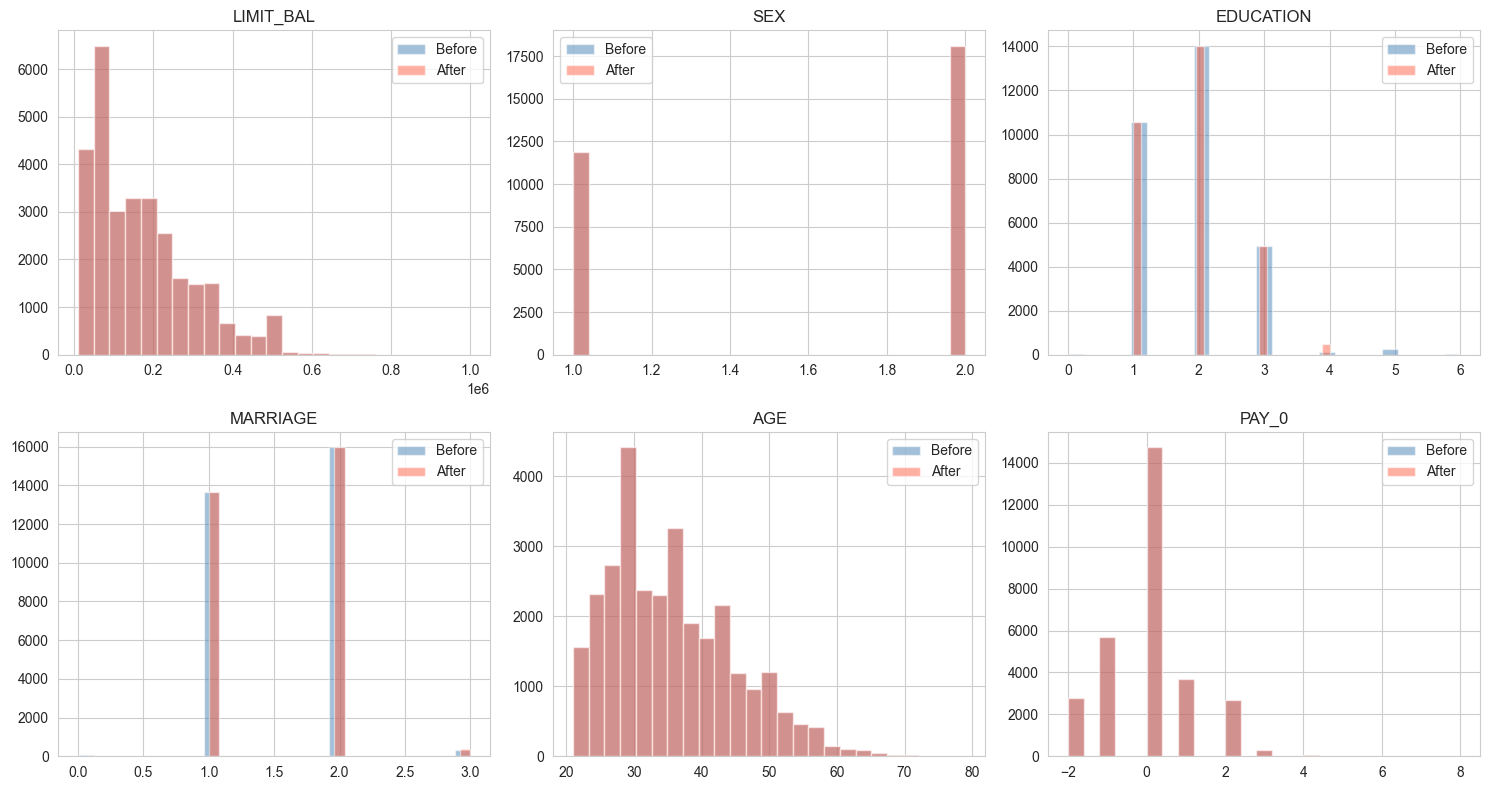

In [5]:
numeric_cols_for_plot = df.select_dtypes(include=[np.number]).columns[:6].tolist()
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(numeric_cols_for_plot):
    if i >= 6: break
    if col in df.columns:
        axes[i].hist(df[col].dropna(), bins=25, alpha=0.5, label='Before', color='steelblue')
    if col in df_imputed.columns:
        axes[i].hist(df_imputed[col], bins=25, alpha=0.5, label='After', color='tomato')
    axes[i].set_title(col); axes[i].legend()
plt.tight_layout(); plt.show()

## 5. Feature Engineering

In [6]:
df_feat = create_features(df_imputed)
print('After feature engineering:', df_feat.shape)
df_feat.head()

After feature engineering: (30000, 35)


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default,TOTAL_BILL,AVG_BILL,TOTAL_PAYMENT,AVG_PAYMENT,BILL_TO_LIMIT_RATIO,PAYMENT_TO_BILL_RATIO,AVG_PAY_STATUS,MAX_PAY_STATUS,NUM_DELAYED_MONTHS,AGE_GROUP,LIMIT_BIN
0,20000.0,2,2,1,24,2,2,-1,-1,-2,-2,3913.0,3102.0,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1,7704.0,1284.000000,689.0,114.833333,0.064200,0.089434,-0.333333,2,2,20s,Low
1,120000.0,2,2,2,26,-1,2,0,0,0,2,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1,17077.0,2846.166667,5000.0,833.333333,0.023718,0.292791,0.500000,2,2,20s,Mid
2,90000.0,2,2,2,34,0,0,0,0,0,0,29239.0,14027.0,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0,101653.0,16942.166667,11018.0,1836.333333,0.188246,0.108388,0.000000,0,0,30s,Mid
3,50000.0,2,2,1,37,0,0,0,0,0,0,46990.0,48233.0,49291.0,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0,231334.0,38555.666667,8388.0,1398.000000,0.771113,0.036259,0.000000,0,0,30s,Low
4,50000.0,1,2,1,57,-1,0,-1,0,0,0,8617.0,5670.0,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0,109339.0,18223.166667,59049.0,9841.500000,0.364463,0.540054,-0.333333,0,0,50s,Low


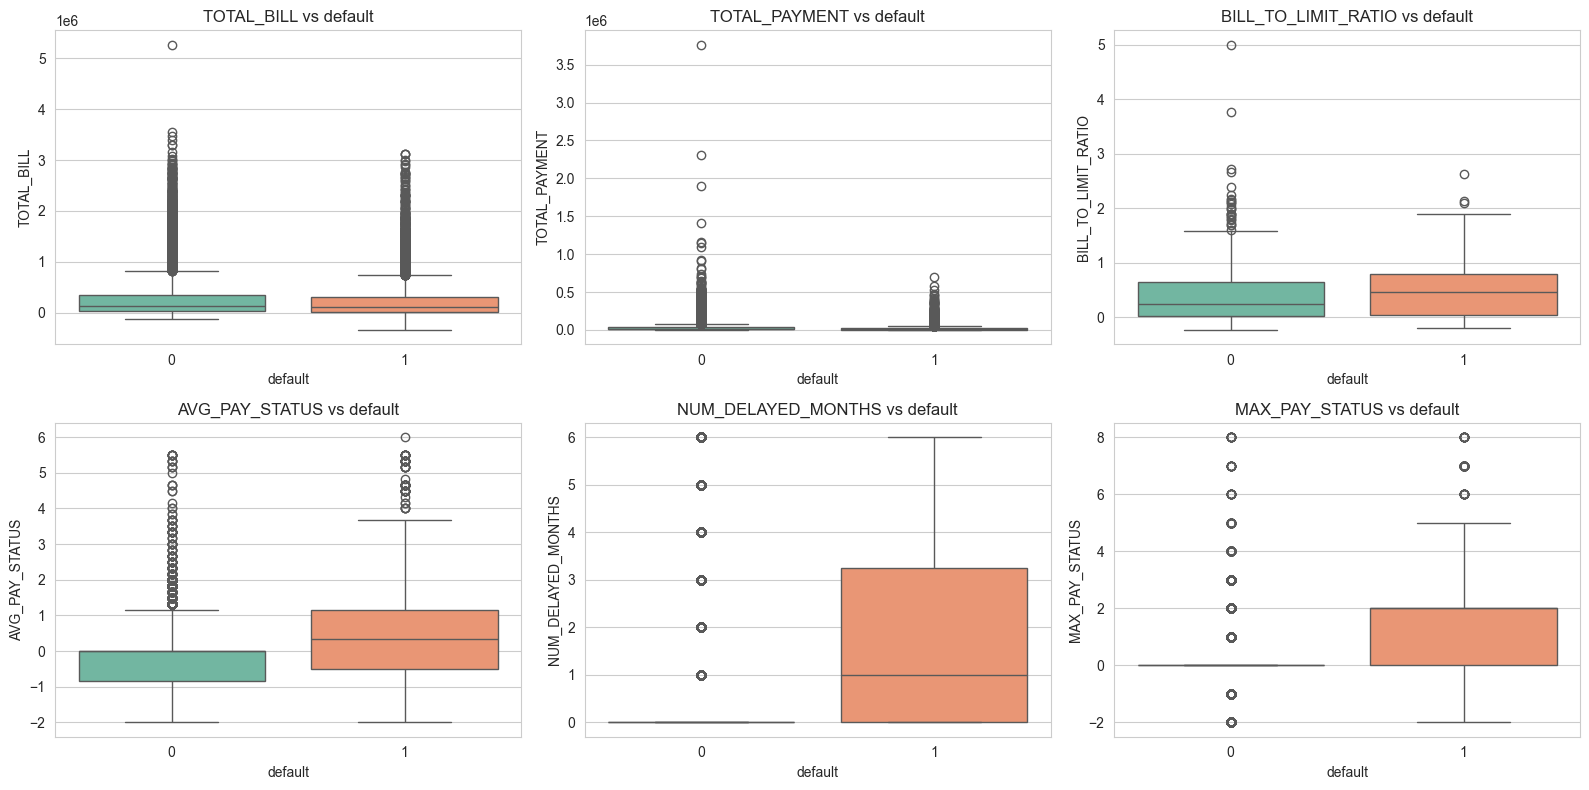

In [7]:
# Engineered features vs target
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(['TOTAL_BILL', 'TOTAL_PAYMENT', 'BILL_TO_LIMIT_RATIO',
                          'AVG_PAY_STATUS', 'NUM_DELAYED_MONTHS', 'MAX_PAY_STATUS']):
    sns.boxplot(x='default', y=col, data=df_feat, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col} vs default')
plt.tight_layout(); plt.show()

## 6. Encode Categorical Features

In [8]:
cat_cols = ['SEX', 'EDUCATION', 'MARRIAGE', 'AGE_GROUP', 'LIMIT_BIN']
df_encoded = pd.get_dummies(df_feat, columns=cat_cols, drop_first=True)
bool_cols = df_encoded.select_dtypes(include=['bool']).columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)
print('After encoding:', df_encoded.shape)
print('New columns:', [c for c in df_encoded.columns if c not in df_feat.columns][:10], '...')

After encoding: (30000, 43)
New columns: ['SEX_2', 'EDUCATION_2', 'EDUCATION_3', 'EDUCATION_4', 'MARRIAGE_2', 'MARRIAGE_3', 'AGE_GROUP_30s', 'AGE_GROUP_40s', 'AGE_GROUP_50s', 'AGE_GROUP_60+'] ...


## 7. Verify & Save Cleaned Dataset

In [9]:
print('Missing values:', df_encoded.isnull().sum().sum())
print('Final shape:', df_encoded.shape)
df_encoded.to_csv('data/credit_card_default_cleaned.csv', index=False)
print('Saved -> data/credit_card_default_cleaned.csv')
df_encoded.head()

Missing values: 0
Final shape: (30000, 43)


Saved -> data/credit_card_default_cleaned.csv


,LIMIT_BAL,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default,TOTAL_BILL,AVG_BILL,TOTAL_PAYMENT,AVG_PAYMENT,BILL_TO_LIMIT_RATIO,PAYMENT_TO_BILL_RATIO,AVG_PAY_STATUS,MAX_PAY_STATUS,NUM_DELAYED_MONTHS,SEX_2,EDUCATION_2,EDUCATION_3,EDUCATION_4,MARRIAGE_2,MARRIAGE_3,AGE_GROUP_30s,AGE_GROUP_40s,AGE_GROUP_50s,AGE_GROUP_60+,LIMIT_BIN_Low,LIMIT_BIN_Mid,LIMIT_BIN_VeryHigh
0,20000.0,24,2,2,-1,-1,-2,-2,3913.0,3102.0,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1,7704.0,1284.000000,689.0,114.833333,0.064200,0.089434,-0.333333,2,2,1,1,0,0,0,0,0,0,0,0,1,0,0
1,120000.0,26,-1,2,0,0,0,2,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1,17077.0,2846.166667,5000.0,833.333333,0.023718,0.292791,0.500000,2,2,1,1,0,0,1,0,0,0,0,0,0,1,0
2,90000.0,34,0,0,0,0,0,0,29239.0,14027.0,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0,101653.0,16942.166667,11018.0,1836.333333,0.188246,0.108388,0.000000,0,0,1,1,0,0,1,0,1,0,0,0,0,1,0
3,50000.0,37,0,0,0,0,0,0,46990.0,48233.0,49291.0,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0,231334.0,38555.666667,8388.0,1398.000000,0.771113,0.036259,0.000000,0,0,1,1,0,0,0,0,1,0,0,0,1,0,0
4,50000.0,57,-1,0,-1,0,0,0,8617.0,5670.0,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0,109339.0,18223.166667,59049.0,9841.500000,0.364463,0.540054,-0.333333,0,0,0,1,0,0,0,0,0,0,1,0,1,0,0
